# Part F - Python Practice: Logistic Regression and Naive Bayes

## Objective

Apply **Logistic Regression** and **Naive Bayes** using `scikit-learn`.

## Dataset

We use a simple **generated machine condition monitoring dataset** with the following features:

- `vibration`
- `temperature`
- `voltage`
- `current`
- `power`
- `status`

The target variable is:

- `status = 0`: Normal machine
- `status = 1`: Faulty machine

## Tasks

1. Load the dataset.
2. Identify input features `X` and target `y`.
3. Split the dataset into training and testing sets.
4. Scale numerical features.
5. Train Logistic Regression.
6. Evaluate using accuracy, precision, recall, F1-score, and confusion matrix.
7. Perform 5-fold cross-validation to tune the following Logistic Regression hyperparameters:
   - `C`: `[0.01, 0.1, 1, 10, 100]`, the inverse of the regularization strength.
   - `max_iter`: `[100, 500, 1000]`, maximum number of training iterations.
8. Train a Naive Bayes model.
9. Compare Logistic Regression and Naive Bayes.


## 0. Import Required Libraries

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

np.random.seed(42)


## Dataset Preparation

Because this tutorial uses a simple generated dataset, the following cell creates the dataset and saves it as a CSV file.

After that, we will follow the Part F tasks exactly, starting with **Task 1: Load the dataset**.


In [59]:
# Generate a challenging machine condition monitoring dataset

np.random.seed(42)

n_normal = 350
n_faulty = 150

# --------------------------------------------------
# Normal machines
# --------------------------------------------------
normal_vibration = np.random.normal(loc=2.4, scale=0.75, size=n_normal)
normal_temperature = np.random.normal(loc=50, scale=8, size=n_normal)
normal_voltage = np.random.normal(loc=219, scale=8, size=n_normal)
normal_current = np.random.normal(loc=5.4, scale=1.0, size=n_normal)

normal_power = normal_voltage * normal_current + np.random.normal(
    loc=0, scale=130, size=n_normal
)

normal_status = np.zeros(n_normal, dtype=int)

# --------------------------------------------------
# Faulty machines
# --------------------------------------------------
faulty_vibration = np.random.normal(loc=3.2, scale=0.95, size=n_faulty)
faulty_temperature = np.random.normal(loc=58, scale=10, size=n_faulty)
faulty_voltage = np.random.normal(loc=214, scale=11, size=n_faulty)
faulty_current = np.random.normal(loc=6.3, scale=1.2, size=n_faulty)

faulty_power = faulty_voltage * faulty_current + np.random.normal(
    loc=0, scale=160, size=n_faulty
)

faulty_status = np.ones(n_faulty, dtype=int)

# --------------------------------------------------
# Combine the data
# --------------------------------------------------
dataset = pd.DataFrame({
    "vibration": np.concatenate([normal_vibration, faulty_vibration]),
    "temperature": np.concatenate([normal_temperature, faulty_temperature]),
    "voltage": np.concatenate([normal_voltage, faulty_voltage]),
    "current": np.concatenate([normal_current, faulty_current]),
    "power": np.concatenate([normal_power, faulty_power]),
    "status": np.concatenate([normal_status, faulty_status])
})

# Avoid unrealistic negative values
dataset["vibration"] = dataset["vibration"].clip(lower=0.1)
dataset["temperature"] = dataset["temperature"].clip(lower=20)
dataset["current"] = dataset["current"].clip(lower=0.1)
dataset["power"] = dataset["power"].clip(lower=1)

# --------------------------------------------------
# Add some borderline cases
# --------------------------------------------------
# Some normal machines behave almost like faulty machines
n_borderline_normal = 45
borderline_normal_idx = dataset[dataset["status"] == 0].sample(
    n=n_borderline_normal,
    random_state=42
).index

dataset.loc[borderline_normal_idx, "vibration"] += np.random.normal(
    loc=0.8,
    scale=0.3,
    size=n_borderline_normal
)

dataset.loc[borderline_normal_idx, "temperature"] += np.random.normal(
    loc=7,
    scale=3,
    size=n_borderline_normal
)

dataset.loc[borderline_normal_idx, "current"] += np.random.normal(
    loc=0.8,
    scale=0.3,
    size=n_borderline_normal
)

# Some faulty machines look almost normal
n_borderline_faulty = 35
borderline_faulty_idx = dataset[dataset["status"] == 1].sample(
    n=n_borderline_faulty,
    random_state=24
).index

dataset.loc[borderline_faulty_idx, "vibration"] -= np.random.normal(
    loc=0.7,
    scale=0.3,
    size=n_borderline_faulty
)

dataset.loc[borderline_faulty_idx, "temperature"] -= np.random.normal(
    loc=6,
    scale=3,
    size=n_borderline_faulty
)

dataset.loc[borderline_faulty_idx, "current"] -= np.random.normal(
    loc=0.7,
    scale=0.3,
    size=n_borderline_faulty
)

# Recalculate power after modifying some samples
dataset["power"] = dataset["voltage"] * dataset["current"] + np.random.normal(
    loc=0,
    scale=150,
    size=len(dataset)
)

dataset["power"] = dataset["power"].clip(lower=1)

# --------------------------------------------------
# Add small label noise
# --------------------------------------------------
# This makes the dataset more realistic:
# a few samples may be mislabeled or ambiguous.
n_noisy_labels = int(0.04 * len(dataset))  # 4% label noise

noisy_idx = dataset.sample(
    n=n_noisy_labels,
    random_state=7
).index

dataset.loc[noisy_idx, "status"] = 1 - dataset.loc[noisy_idx, "status"]

# --------------------------------------------------
# Shuffle the rows
# --------------------------------------------------
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the dataset
dataset.to_csv("machine_condition_monitoring.csv", index=False)

print("Dataset generated and saved as: machine_condition_monitoring.csv")
dataset.head()

Dataset generated and saved as: machine_condition_monitoring.csv


,vibration,temperature,voltage,current,power,status
0,2.662229,80.200879,212.488910,6.570947,1524.586715,1
1,3.573483,57.772568,226.780436,4.256995,917.216785,0
2,2.494653,78.740827,207.205829,5.520752,1202.278878,1
3,2.338691,59.368325,214.434030,6.495121,1981.710616,1
4,2.279036,45.757939,215.524030,7.042015,1550.239822,0


# Task 1. Load the Dataset

In [60]:
df = pd.read_csv("machine_condition_monitoring.csv")

df.head()


,vibration,temperature,voltage,current,power,status
0,2.662229,80.200879,212.488910,6.570947,1524.586715,1
1,3.573483,57.772568,226.780436,4.256995,917.216785,0
2,2.494653,78.740827,207.205829,5.520752,1202.278878,1
3,2.338691,59.368325,214.434030,6.495121,1981.710616,1
4,2.279036,45.757939,215.524030,7.042015,1550.239822,0


In [61]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (500, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vibration    500 non-null    float64
 1   temperature  500 non-null    float64
 2   voltage      500 non-null    float64
 3   current      500 non-null    float64
 4   power        500 non-null    float64
 5   status       500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [62]:
df.describe()


,vibration,temperature,voltage,current,power,status
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.649601,52.522886,218.036587,5.736193,1239.543473,0.304000
std,0.859842,9.674154,9.113831,1.122334,295.750438,0.460443
min,0.100000,27.685468,185.814330,2.503745,316.512817,0.000000
25%,2.039921,45.917141,212.514424,5.014007,1038.730841,0.000000
50%,2.609614,52.278974,218.657024,5.706228,1239.726415,0.000000
75%,3.165719,59.138401,224.067935,6.468544,1421.803810,1.000000
max,5.289549,84.443433,240.538770,8.862878,2093.028867,1.000000


In [63]:
df["status"].value_counts()


,count
status,
0,348
1,152


# Task 2. Identify Input Features `X` and Target `y`

The input features are:

- `vibration`
- `temperature`
- `voltage`
- `current`
- `power`

The target variable is:

- `status`


In [64]:
features = ["vibration", "temperature", "voltage", "current", "power"]

X = df[features]
y = df["status"]

print("Input features X:")
display(X.head())

print("Target y:")
display(y.head())


Input features X:


,vibration,temperature,voltage,current,power
0,2.662229,80.200879,212.488910,6.570947,1524.586715
1,3.573483,57.772568,226.780436,4.256995,917.216785
2,2.494653,78.740827,207.205829,5.520752,1202.278878
3,2.338691,59.368325,214.434030,6.495121,1981.710616
4,2.279036,45.757939,215.524030,7.042015,1550.239822


Target y:


,status
0,1
1,0
2,1
3,1
4,0


# Task 3. Split the Dataset into Training and Testing Sets

We use:

- 80% for training
- 20% for testing

We also use `stratify=y` to preserve the same class distribution in both sets.


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


Training set size: (400, 5)
Testing set size: (100, 5)

Training target distribution:
status
0    0.695
1    0.305
Name: proportion, dtype: float64

Testing target distribution:
status
0    0.7
1    0.3
Name: proportion, dtype: float64


# Task 4. Scale Numerical Features

Scaling is important for Logistic Regression because the features have different ranges.

For example:

- `vibration` may be between 1 and 6
- `voltage` may be around 200
- `power` may be around 1000 or more

We use `StandardScaler`.


In [66]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First five rows after scaling:")
pd.DataFrame(X_train_scaled, columns=features).head()


First five rows after scaling:


,vibration,temperature,voltage,current,power
0,0.318915,0.805143,-1.007098,0.524393,-0.671093
1,-1.592261,0.064523,0.078208,0.189855,-0.263063
2,-0.488947,1.730019,0.071578,-0.272602,0.104597
3,-0.762188,-0.019218,-0.307042,-0.368135,-0.751428
4,0.374190,-1.010546,-1.459198,-0.344634,-0.043846


# Task 5. Train Logistic Regression

In [67]:
logistic_model = LogisticRegression(C=0.01, random_state=42, max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)


# Task 6. Evaluate Logistic Regression

We evaluate the model using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix


In [68]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Evaluation")
print("------------------------------")
print(f"Accuracy : {accuracy_logistic:.3f}")
print(f"Precision: {precision_logistic:.3f}")
print(f"Recall   : {recall_logistic:.3f}")
print(f"F1-score : {f1_logistic:.3f}")


Logistic Regression Evaluation
------------------------------
Accuracy : 0.690
Precision: 0.400
Recall   : 0.067
F1-score : 0.114


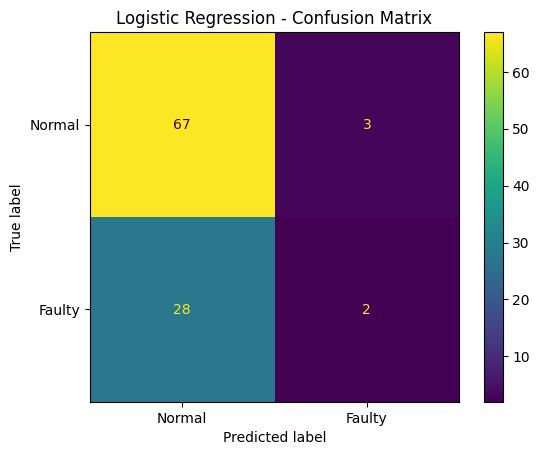

In [69]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Normal", "Faulty"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


In [70]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_logistic, target_names=["Normal", "Faulty"]))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

      Normal       0.71      0.96      0.81        70
      Faulty       0.40      0.07      0.11        30

    accuracy                           0.69       100
   macro avg       0.55      0.51      0.46       100
weighted avg       0.61      0.69      0.60       100



# Task 7. Perform 5-Fold Cross-Validation for Hyperparameter Tuning

We tune the following Logistic Regression hyperparameters:

- `C`: `[0.01, 0.1, 1, 10, 100]`
  - `C` is the inverse of the regularization strength.
  - Smaller `C` means stronger regularization.
  - Larger `C` means weaker regularization.

- `max_iter`: `[100, 500, 1000]`
  - This is the maximum number of training iterations.

We use `GridSearchCV` with 5-fold cross-validation.


In [71]:
# We use a pipeline to ensure that scaling is applied correctly inside cross-validation.
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__max_iter": [100, 500, 1000]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best hyperparameters:")
print(grid_search.best_params_)

print(f"Best 5-fold cross-validation F1-score: {grid_search.best_score_:.3f}")


Best hyperparameters:
{'classifier__C': 1, 'classifier__max_iter': 100}
Best 5-fold cross-validation F1-score: 0.565


In [72]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results[[
    "param_classifier__C",
    "param_classifier__max_iter",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)


,param_classifier__C,param_classifier__max_iter,mean_test_score,std_test_score,rank_test_score
6,1.0,100,0.565159,0.033622,1
7,1.0,500,0.565159,0.033622,1
13,100.0,500,0.565159,0.033622,1
12,100.0,100,0.565159,0.033622,1
11,10.0,1000,0.565159,0.033622,1
10,10.0,500,0.565159,0.033622,1
9,10.0,100,0.565159,0.033622,1
8,1.0,1000,0.565159,0.033622,1
14,100.0,1000,0.565159,0.033622,1
3,0.1,100,0.552566,0.062760,10


## Evaluate the Best Logistic Regression Model on the Test Set

In [73]:
best_logistic_model = grid_search.best_estimator_

y_pred_best_logistic = best_logistic_model.predict(X_test)

accuracy_best_logistic = accuracy_score(y_test, y_pred_best_logistic)
precision_best_logistic = precision_score(y_test, y_pred_best_logistic)
recall_best_logistic = recall_score(y_test, y_pred_best_logistic)
f1_best_logistic = f1_score(y_test, y_pred_best_logistic)

print("Best Logistic Regression Evaluation")
print("-----------------------------------")
print(f"Accuracy : {accuracy_best_logistic:.3f}")
print(f"Precision: {precision_best_logistic:.3f}")
print(f"Recall   : {recall_best_logistic:.3f}")
print(f"F1-score : {f1_best_logistic:.3f}")


Best Logistic Regression Evaluation
-----------------------------------
Accuracy : 0.700
Precision: 0.500
Recall   : 0.300
F1-score : 0.375


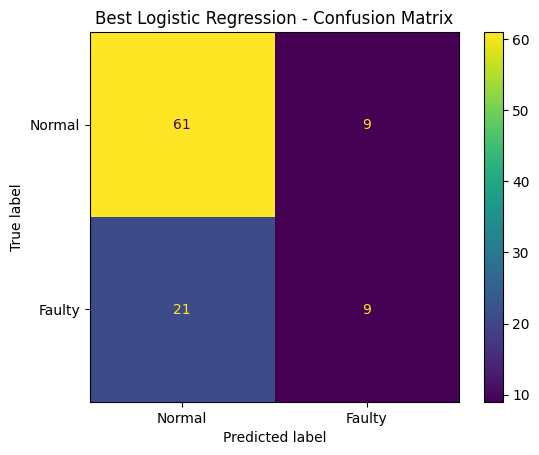

In [74]:
cm_best_logistic = confusion_matrix(y_test, y_pred_best_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_logistic,
    display_labels=["Normal", "Faulty"]
)

disp.plot()
plt.title("Best Logistic Regression - Confusion Matrix")
plt.show()


# Task 8. Train a Naive Bayes Model

We use `GaussianNB`, which is appropriate for continuous numerical features.

Naive Bayes is a probabilistic classifier.
It estimates the probability of each class and predicts the class with the highest probability.


In [75]:
naive_bayes_model = GaussianNB()

naive_bayes_model.fit(X_train_scaled, y_train)

y_pred_nb = naive_bayes_model.predict(X_test_scaled)


## Evaluate Naive Bayes

In [76]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Evaluation")
print("----------------------")
print(f"Accuracy : {accuracy_nb:.3f}")
print(f"Precision: {precision_nb:.3f}")
print(f"Recall   : {recall_nb:.3f}")
print(f"F1-score : {f1_nb:.3f}")


Naive Bayes Evaluation
----------------------
Accuracy : 0.700
Precision: 0.500
Recall   : 0.367
F1-score : 0.423


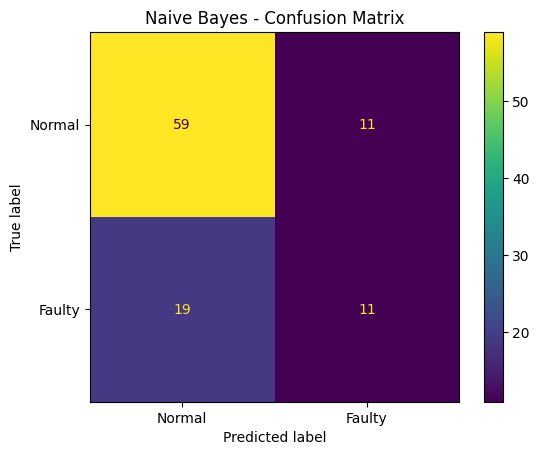

In [77]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Normal", "Faulty"]
)

disp.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()


In [78]:
print("Classification Report - Naive Bayes")
print(classification_report(y_test, y_pred_nb, target_names=["Normal", "Faulty"]))


Classification Report - Naive Bayes
              precision    recall  f1-score   support

      Normal       0.76      0.84      0.80        70
      Faulty       0.50      0.37      0.42        30

    accuracy                           0.70       100
   macro avg       0.63      0.60      0.61       100
weighted avg       0.68      0.70      0.69       100



# Task 9. Compare Logistic Regression and Naive Bayes

In [79]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Best Logistic Regression",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_best_logistic,
        accuracy_nb
    ],
    "Precision": [
        precision_logistic,
        precision_best_logistic,
        precision_nb
    ],
    "Recall": [
        recall_logistic,
        recall_best_logistic,
        recall_nb
    ],
    "F1-score": [
        f1_logistic,
        f1_best_logistic,
        f1_nb
    ]
})

comparison


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.69,0.4,0.066667,0.114286
1,Best Logistic Regression,0.70,0.5,0.300000,0.375000
2,Naive Bayes,0.70,0.5,0.366667,0.423077


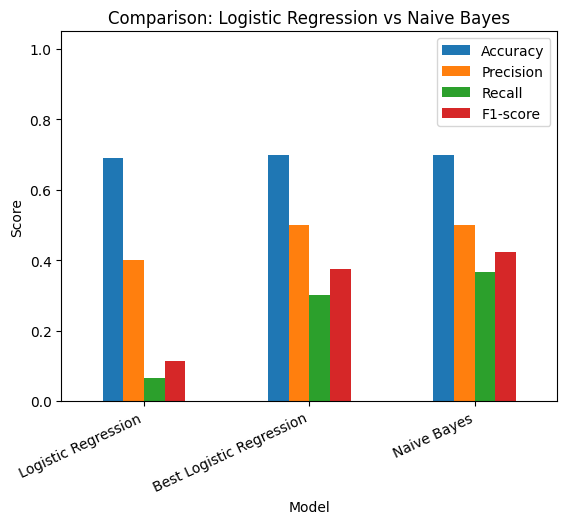

In [80]:
comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar")

plt.title("Comparison: Logistic Regression vs Naive Bayes")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.show()


## Interpretation

The comparison table allows us to answer the following questions:

1. Which model has the highest accuracy?
2. Which model has the highest precision?
3. Which model has the highest recall?
4. Which model has the highest F1-score?

In machine condition monitoring, **recall for the faulty class** is very important because we want to avoid missing faulty machines.

A model with high accuracy but low recall for faulty machines may not be useful in practice.


# Final Questions for Students

1. Why do we split the dataset into training and testing sets?
2. Why do we scale the numerical features?
3. What does the confusion matrix tell us that accuracy alone does not?
4. In machine condition monitoring, why is recall important?
5. What is the role of the hyperparameter `C` in Logistic Regression?
6. What is the role of the hyperparameter `max_iter` in Logistic Regression?
7. Which model performs better: Logistic Regression or Naive Bayes? Justify your answer using the results.
